# Week 3 Studio — Modes and Misuse

Solutions to Tasks 1–4 of [`README.md`](README.md).
Built on the given files: `modes.py`, `mdhash.py`, `data.py`, and on the
functions implemented in [`starter.py`](starter.py).

**Core idea:** AES and SHA-256 come out of all three attacks intact. What breaks
is the **mode** or the **construction** wrapped around the primitive — a *misuse*.


In [1]:
import os

from modes import ecb_encrypt, cbc_encrypt, distinct_blocks, ctr_keystream, xor
from mdhash import md_hash, bad_mac, good_mac
from data import (IMAGE, ECB_DISTINCT_EXPECTED, CBC_DISTINCT_EXPECTED,
                  M1, M2, CRIB, MAC_SECRET, MAC_MSG, MAC_EXTENSION)

key = os.urandom(16)
print("setup ready — random key of", len(key), "bytes")


setup ready — random key of 16 bytes


## Task 1 — ECB vs CBC

`ecb_leak_count` ECB-encrypts the image and counts the distinct ciphertext blocks.
Because the block cipher is deterministic, that number equals the number of
distinct *plaintext* blocks: the structure leaks 1:1.


In [2]:
def ecb_leak_count(image: bytes, key: bytes) -> int:
    """ECB-encrypt the image and count the distinct ciphertext blocks."""
    return distinct_blocks(ecb_encrypt(image, key))


In [3]:
ecb_distinct = ecb_leak_count(IMAGE, key)
cbc_distinct = distinct_blocks(cbc_encrypt(IMAGE, key, os.urandom(3)))

print(f"plaintext : {distinct_blocks(IMAGE)} distinct blocks")
print(f"ECB       : {ecb_distinct} distinct (expected {ECB_DISTINCT_EXPECTED}) -> leaks the structure")
print(f"CBC       : {cbc_distinct} distinct (expected {CBC_DISTINCT_EXPECTED}) -> hides it")
print("same image, same cipher, different MODE")


plaintext : 2 distinct blocks
ECB       : 2 distinct (expected 2) -> leaks the structure
CBC       : 96 distinct (expected 96) -> hides it
same image, same cipher, different MODE


**Bonus — the ECB penguin.** `IMAGE` has two flat regions: ECB visibly preserves
them, CBC does not.


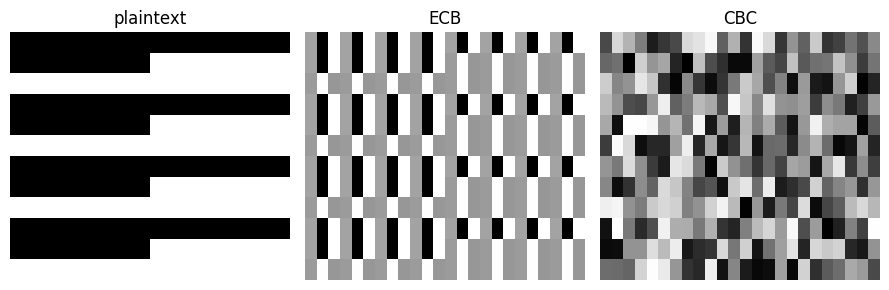

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def as_img(data, w=24):
    a = np.frombuffer(data[:len(data) // w * w], dtype=np.uint8)
    return a.reshape(-1, w)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (title, data) in zip(axes, [
        ("plaintext", IMAGE),
        ("ECB", ecb_encrypt(IMAGE, key)),
        ("CBC", cbc_encrypt(IMAGE, key, os.urandom(3)))]):
    ax.imshow(as_img(data), cmap="gray", aspect="auto")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Task 2 — CTR with a reused nonce

Same key **and** same nonce ⇒ same keystream ⇒ it cancels out:

$$c_1 \oplus c_2 = m_1 \oplus m_2 \quad\Rightarrow\quad m_2 = c_1 \oplus c_2 \oplus m_1$$

This is week 2's two-time pad, verbatim, on a modern mode.


In [5]:
def recover_second_plaintext(c1: bytes, c2: bytes, known_m1: bytes) -> bytes:
    """The shared keystream cancels out: m2 = c1 XOR c2 XOR m1."""
    return xor(xor(c1, c2), known_m1)[:len(known_m1)]


In [6]:
nonce = os.urandom(8)                       # the BUG: the same nonce for both
ks = ctr_keystream(key, nonce, max(len(M1), len(M2)))
c1, c2 = xor(M1, ks), xor(M2, ks)

print("c1 XOR c2 == m1 XOR m2 ?", xor(c1, c2) == xor(M1, M2))
recovered = recover_second_plaintext(c1, c2, M1)
print("recovered m2:", recovered)
print("correct?", recovered == M2)


c1 XOR c2 == m1 XOR m2 ? True
recovered m2: b'the quarterly meeting moved to three pm'
correct? True


**Crib-dragging** (without knowing `m1`): drag `CRIB = b"transfer"` across
`c1 ⊕ c2`; wherever the result comes out readable, that is where the crib sat in
the other message.


In [7]:
x = xor(c1, c2)
for i in range(len(x) - len(CRIB) + 1):
    frag = xor(x[i:i + len(CRIB)], CRIB)
    if all(b == 32 or 97 <= b <= 122 for b in frag):   # lowercase/space only
        print(f"offset {i:2d} -> {frag}")


offset  0 -> b'the quar'


## Task 3 — Length extension against `H(secret‖msg)`

A Merkle–Damgård digest **is** the full internal state, so hashing can be
*resumed* from the observed tag. The attacker only ever needs
`(msg, tag, len(secret))` — never the secret itself.


In [8]:
def forge_extension(observed_msg, observed_tag, secret_len, extension):
    """Forge a valid bad_mac tag without knowing the secret."""
    total = secret_len + len(observed_msg)
    pad = bytes((-total) % 4)                          # the hash's glue padding
    forged_msg = observed_msg + pad + extension
    forged_tag = md_hash(extension, iv=observed_tag)   # resume from the tag
    return forged_msg, forged_tag


In [9]:
tag = bad_mac(MAC_SECRET, MAC_MSG)          # all the attacker gets to observe
print(f"observed msg : {MAC_MSG!r}")
print(f"observed tag : {tag:#010x}")

forged_msg, forged_tag = forge_extension(MAC_MSG, tag, len(MAC_SECRET), MAC_EXTENSION)
server_tag = bad_mac(MAC_SECRET, forged_msg)   # what the server computes WITH the secret

print(f"\nforged msg   : {forged_msg!r}")
print(f"forged tag   : {forged_tag:#010x}")
print(f"server tag   : {server_tag:#010x}")
print("does the server accept the forgery?", forged_tag == server_tag)


observed msg : b'amount=100&to=alice'
observed tag : 0xa0da1bb5

forged msg   : b'amount=100&to=alice\x00\x00&to=attacker'
forged tag   : 0x9a6fc866
server tag   : 0x9a6fc866
does the server accept the forgery? True


**HMAC stops the same attack.** It exposes no resumable internal state, so
without the key there is no path to forging the tag.


In [10]:
import hmac

forged_guess = good_mac(b"", MAC_MSG + MAC_EXTENSION)   # attempt without the key
real_tag = good_mac(MAC_SECRET, MAC_MSG + MAC_EXTENSION)

print("does HMAC accept the forgery?", hmac.compare_digest(forged_guess, real_tag))
print("-> a better CONSTRUCTION, not a better hash")


does HMAC accept the forgery? False
-> a better CONSTRUCTION, not a better hash


## Provided tests

`starter.py` already contains the three functions implemented above.


In [11]:
import subprocess, sys
r = subprocess.run([sys.executable, "test_modes.py"], capture_output=True,
                   text=True, encoding="utf-8")
print(r.stdout or r.stderr)

  ok  ECB leaks 2 blocks, CBC hides (96) — the MODE decided, not the cipher
  ok  CTR nonce reuse recovered m2 = week-2 two-time pad on a modern mode
  ok  H(secret‖msg) guarantee COLLAPSED — valid tag forged without the key
  ok  HMAC rejected the forgery — better construction, not a better hash

all 4 tests pass



## Task 4 — Control Scorecard

Filled in against [`../../resources/control-scorecard.md`](../../resources/control-scorecard.md).
Here the **control under evaluation is the mode or the construction itself** — the
question is never "is AES strong?" but *what does this wrapper guarantee, against
which adversary, and how do we know?*

Starting point (README), stated as guarantee **plus its condition** (axis 2):

| Construction | Guarantee (axis 2) | Condition it depends on / how it fails | Classification |
|---|---|---|---|
| **ECB** | confidentiality of an *individual* block, nothing more | holds only **if no plaintext block ever repeats** — false for any structured data, so it **leaks structure** (2 distinct blocks out of 96) | mode misuse |
| **CBC** | confidentiality of the message | **the IV must be unpredictable and never reused** under the key; and it provides **no integrity** (malleable, padding oracles) | mode misuse |
| **CTR** | confidentiality of the message | **the (key, nonce) pair must never repeat**; if it does ⇒ two-time pad, `c1 ⊕ c2 = m1 ⊕ m2`; **no integrity** either | mode misuse |
| **`H(secret‖msg)`** | *appears* to authenticate: "only the holder of the secret can produce the tag" | false for Merkle–Damgård: the digest **is** the internal state ⇒ **length extension** forges valid tags without the key. **No guarantee at all**, not a conditional one | construction misuse |
| **HMAC** | existential unforgeability, immune to length extension | **if** the key is secret and high-entropy **and** the tag comparison is constant-time | — (holds) |

**All three breaks are misuse, not a primitive break.** AES and SHA-256 are
untouched; what broke was the mode (ECB, CTR nonce) or the construction (`H(k‖m)`).
Naming the condition is the whole skill: *AES-CTR is confidential **provided** a
nonce is never repeated under the same key.*

---

### Scorecard 1 — ECB mode

| Axis | Before (no encryption) | After control (ECB) | Evidence |
|---|---|---|---|
| Threat model | passive attacker holding the plaintext | passive attacker holding **only the ciphertext**: no key, no oracle, no chosen plaintext; the only capability needed is comparing blocks for equality | `data.py` (`IMAGE`), Task 1 cells |
| Guarantee | none | confidentiality of a block's *contents* **if and only if no plaintext block repeats** | axis-2 table above |
| Coverage | 0/96 blocks hidden | **2 distinct ciphertext blocks out of 96** — the 2 flat regions survive 1:1, so 100 % of the structure leaks | Task 1 output; `ECB_DISTINCT_EXPECTED = 2` |
| **Bypass** | — | **found, and it needs no key**: count distinct blocks / render the image — the penguin is visible in the ciphertext | Task 1 bonus (matplotlib render) |
| FP cost | — | **0 %** — legitimate decryption is unaffected; ECB breaks nothing for the key holder | round trip in `test_modes.py` |
| Op cost | 0 | 1 block-cipher call per 3-byte block (96 per image); fully parallelizable; **no wall-clock or RAM measurement taken** | not measured |
| Observability | — | **none**: nothing logs "your structure leaked". The leak is visible only to whoever compares blocks — i.e. the attacker | Task 1 cells |
| Failure mode | — | **silently degrades**: the data is still "encrypted", nothing errors, and the failure is invisible from the defender's side | Task 1 output |

### Scorecard 2 — CBC mode

| Axis | Before (ECB) | After control (CBC) | Evidence |
|---|---|---|---|
| Threat model | same passive ciphertext-only attacker | unchanged for our test; a stronger attacker (chosen plaintext, a padding oracle, predictable IVs) was **not** modelled | Task 1 cells |
| Guarantee | block-level only | confidentiality of the message **provided the IV is unpredictable and never reused under the key**; **no integrity claim whatsoever** | axis-2 table above |
| Coverage | 2/96 distinct | **96/96 distinct ciphertext blocks** — the chaining destroys the repeated structure | Task 1 output; `CBC_DISTINCT_EXPECTED = 96` |
| **Bypass** | the leak was trivial | **not attempted against CBC** — no padding oracle, no predictable-IV test, no bit-flip. This axis is **asserted, not evaluated** | — (see honesty clause) |
| FP cost | 0 % | **0 %** — decryption round-trips for the key holder | `test_modes.py` |
| Op cost | parallel | **serial** encryption (each block waits on the previous) plus 3 bytes of IV shipped per message; **not timed** | not measured |
| Observability | none | none: an IV reused by mistake raises no error and produces no log line | — |
| Failure mode | silent | **fails open, silently**: a repeated or predictable IV still encrypts and decrypts fine; the weakness surfaces only in the attacker's analysis | — |

### Scorecard 3 — CTR mode with nonce reuse

| Axis | Before (plaintext) | After control (CTR, nonce reused) | Evidence |
|---|---|---|---|
| Threat model | — | passive attacker who captures **two ciphertexts produced under the same (key, nonce)** and holds either one known plaintext **or** a plausible crib. No key, no oracle, cost = one XOR | Task 2 cells |
| Guarantee | none | confidentiality **provided the (key, nonce) pair never repeats**. The condition was violated ⇒ **the guarantee is void**, and the strength of AES contributes nothing | axis-2 table above |
| Coverage | — | **39/39 bytes of `m2` recovered exactly** from one message pair; crib-dragging also located `b"transfer"` at offset 0 without knowing `m1` | Task 2 outputs (`correct? True`, `offset 0`) |
| **Bypass** | — | **working bypass**: `m2 = c1 ⊕ c2 ⊕ m1` — full plaintext recovery, week 2's two-time pad verbatim on a modern mode | `recover_second_plaintext`, `test_modes.py` |
| FP cost | — | **0 %** — nothing breaks for legitimate users, which is exactly why this bug survives into production | Task 2 round trip |
| Op cost | 0 | one hash call per keystream block, parallelizable and precomputable; 8 bytes of nonce per message; **not timed** | not measured |
| Observability | — | **none**: both encryptions succeed. Only a system that *logs and checks nonces per key* could ever see this; ours does not | Task 2 cells |
| Failure mode | — | **fails open, silently**: no exception, no alert, total confidentiality loss | Task 2 output |

### Scorecard 4 — `H(secret‖msg)` MAC vs. HMAC

| Axis | Before (`bad_mac` = `H(secret‖msg)`) | After control (HMAC-SHA256) | Evidence |
|---|---|---|---|
| Threat model | remote attacker who observes **one** `(msg, tag)` pair, knows or brute-forces `len(secret)`, and can submit a message to the verifier. **Never sees the key** | unchanged — same attacker, same information | Task 3 cells; `data.py` |
| Guarantee | *appears* to authenticate; in reality **no guarantee at all** against a length-extension attacker | unforgeability **provided** the key stays secret and has enough entropy and the tag comparison is constant-time; length extension does not apply because the inner state is never exposed | axis-2 table above |
| Coverage | **1/1 forgery accepted** by the server, for the attacker-chosen extension `&to=attacker` | **1/1 forgery rejected**, and the legitimate tag still accepted | Task 3 outputs; `test_modes.py` (4/4 pass) |
| **Bypass** | **working bypass**: resume the hash from the observed tag — `pad = bytes((-total) % 4)`, `md_hash(extension, iv=tag)` — forged tag equals the server's tag | **bypass attempted and it failed**: the same trick finds no resumable state to seize; without the key `good_mac` produces an unrelated digest | `forge_extension`; `hmac.compare_digest(...) == False` |
| FP cost | 0 % — honest messages verify | **0 %** — the genuine tag still verifies; the cost is a 32-byte tag instead of 4 | Task 3 / HMAC cells |
| Op cost | one pass over `secret‖msg`, 4-byte tag | **two** nested SHA-256 passes and a 32-byte tag; negligible in practice but **not measured here** | not measured |
| Observability | **none — this is the sharp edge**: the server accepts the forged request and logs it as *valid*. The forgery is indistinguishable from legitimate traffic in the log | a verification failure is a discrete, loggable, alertable event | Task 3 output (`server accepts: True`) |
| Failure mode | **fails open**: a forged tag is treated as authentic and the appended `&to=attacker` is honoured | **fails closed**: a bad tag is rejected | `test_modes.py` |

---

### Self-scoring (evidence quality, 0–4 per the rubric)

| Axis | ECB | CBC | CTR | `H(k‖m)` | HMAC |
|---|:--:|:--:|:--:|:--:|:--:|
| 1 Threat model | 3 | 2 | 3 | 3 | 3 |
| 2 Guarantee | 4 | 3 | 4 | 4 | 4 |
| 3 Coverage | 3 | 3 | 2 | 2 | 2 |
| 4 **Bypass** | 4 | **1** | 4 | 4 | 4 |
| 5 FP cost | 2 | 2 | 2 | 2 | 2 |
| 6 Op cost | **1** | **1** | **1** | **1** | **1** |
| 7 Observability | 3 | 2 | 3 | 4 | 3 |
| 8 Failure mode | 3 | 2 | 3 | 4 | 3 |

The weak columns are the honest ones: **op cost was never measured** (no timings,
no memory), **false positives were never measured against a benign corpus** (only a
round trip), **CBC was never attacked at all**, and coverage sits far below the
rubric's ≥ 20-payload bar — one image, one message pair, one forged extension.

### Where we may have been unfair, and what we did not test

- **The primitives are toys.** `block_cipher` is truncated SHA-256 over a 3-byte
  block, and the hash is a 32-bit multiply–add. The attacks rely only on
  determinism and on Merkle–Damgård resumability, which real AES and real
  MD5/SHA-1/SHA-256 do share — but nothing here measures real AES.
- **A 3-byte block flatters the ECB result.** Real 16-byte AES blocks repeat far
  less often; the penguin needs genuinely large flat regions.
- **The 32-bit tag flatters the forgery.** That tag space is brute-forceable in
  2³² tries *without* any clever attack, so our forgery proves the construction is
  broken but understates how much length extension actually buys against real
  SHA-256 (resume-from-digest vs. 2²⁵⁶).
- **`secret_len` was handed to us** by `data.py`. A real attacker brute-forces it —
  cheap, but we never ran that loop, so "the attacker only needs the length" is
  demonstrated without the cost of learning it.
- **Attacker and defender got very unequal effort.** We wrote the attacks and never
  tried to harden the naive MAC (`H(msg‖secret)`, a length prefix, truncated tags).
  Those variants have their own attacks, and we ran none of them.
- **CBC got a free pass**: measured only by distinct-block count. No padding oracle,
  no predictable-IV attempt, no bit-flip. Its row is the least trustworthy here.
- **Coverage is a sample, not the space**: 1 image, 1 message pair, 1 extension.
- **Thought of and not tried**: bit-flipping malleability against CTR (which would
  have shown the missing integrity directly), a birthday estimate for random 96-bit
  nonce collisions, and timing the comparison inside `bad_mac` for a side channel.

### Quick question — unique nonce but the key reused across a million messages

Yes, CTR is still confidential. The condition is not "one key per message" but that
the **(key, nonce) pair never repeats** — reusing a key with unique nonces is the
intended use. Two caveats: with random 96-bit nonces there is a birthday-collision
risk (which is why GCM prefers counters and imposes per-key message limits), and CTR
**never** provides integrity — that requires a MAC or an AEAD such as GCM.
